# LLM vs modelos clásicos — ¿Puede un LLM reemplazar a la regresión logística o al K-Means?

_Comparación cabeza a cabeza en clasificación supervisada (churn) y segmentación no supervisada de clientes_

**Módulo 3 — Introducción a AI Engineering** | DSRP Machine Learning Engineering
**Profesor:** Miguel Arquez

![AI Engineering](assets/header.png)

## 1. La pregunta del millón

Ahora que tenemos LLMs que "entienden" lenguaje natural, surge una tentación recurrente:

> _"¿Para qué entrenar un modelo si puedo simplemente describirle el cliente al LLM y pedirle que prediga / segmente?"_

Este notebook responde con datos. Vamos a:

1. **Caso supervisado**: predecir churn de clientes Telco con un LLM (zero-shot y few-shot) y compararlo contra la **regresión logística** del notebook 04 del módulo 1.
2. **Caso no supervisado**: segmentar clientes con un LLM y compararlo contra el **K-Means** del notebook 02 del módulo 2.
3. Cuantificar **calidad, costo y latencia** de cada enfoque.

Spoiler: ningún enfoque "gana" siempre — la respuesta depende del problema, los datos disponibles y las restricciones de negocio.

## 2. Setup

Cargamos el dataset de Telco (mismo que usamos en módulos 1 y 2) y la API key de OpenAI.

In [3]:
import os
from pathlib import Path

try:
    from dotenv import load_dotenv
    load_dotenv(Path('.') / 'ai.env')
except ImportError:
    pass

if not os.environ.get('OPENAI_API_KEY'):
    print('⚠️  No hay OPENAI_API_KEY — las celdas con LLM no funcionarán.')
else:
    print('✅ API key encontrada.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

DATA = Path('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(DATA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
print('Shape:', df.shape, '| Tasa churn:', round(df['Churn_bin'].mean(), 3))

✅ API key encontrada.
Shape: (7032, 22) | Tasa churn: 0.266


## 3. Caso supervisado — predicción de churn

### 3.1 Baseline clásico: regresión logística

Reentrenamos rápido el modelo de módulo 1 (notebook 04) sobre el mismo dataset y evaluamos en una muestra pequeña que también usaremos para el LLM.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
            'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']

X = pd.get_dummies(df[num_cols + cat_cols], columns=cat_cols, drop_first=True)
y = df['Churn_bin']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_tr)
logit  = LogisticRegression(max_iter=1000).fit(scaler.transform(X_tr), y_tr)

# Tomamos una muestra pequeña del test para comparar contra el LLM (control de costo)
N_MUESTRA = 100
muestra_idx = X_te.sample(n=N_MUESTRA, random_state=42).index
X_te_s    = X_te.loc[muestra_idx]
y_te_s    = y_te.loc[muestra_idx]
df_muestra = df.loc[muestra_idx]   # filas originales con texto, para el LLM

pred_lr = logit.predict(scaler.transform(X_te_s))
proba_lr = logit.predict_proba(scaler.transform(X_te_s))[:, 1]

print(f'--- Regresión logística sobre {N_MUESTRA} clientes ---')
print(f'Accuracy : {accuracy_score(y_te_s, pred_lr):.3f}')
print(f'Precision: {precision_score(y_te_s, pred_lr):.3f}')
print(f'Recall   : {recall_score(y_te_s, pred_lr):.3f}')
print(f'F1       : {f1_score(y_te_s, pred_lr):.3f}')
print(f'ROC AUC  : {roc_auc_score(y_te_s, proba_lr):.3f}')

--- Regresión logística sobre 100 clientes ---
Accuracy : 0.870
Precision: 0.789
Recall   : 0.625
F1       : 0.698
ROC AUC  : 0.878


### 3.2 Enfoque LLM — convertir cada cliente a texto y pedir clasificación

La idea: en vez de features numéricos, **describimos al cliente en lenguaje natural** y le pedimos al LLM que prediga si va a hacer churn.

> _"Cliente femenina de 65 años, con contrato month-to-month, fibra óptica, 5 meses de antigüedad y cargo mensual de 95 USD. ¿Hará churn?"_

In [5]:
def cliente_a_texto(row):
    """Convierte una fila del DataFrame en una descripción en lenguaje natural."""
    senior = 'es senior (65+)' if row['SeniorCitizen'] == 1 else 'no es senior'
    return (
        f"Cliente {row['gender']}, {senior}, "
        f"{'con' if row['Partner']=='Yes' else 'sin'} pareja, "
        f"{'con' if row['Dependents']=='Yes' else 'sin'} dependientes. "
        f"Lleva {row['tenure']} meses con la compañía. "
        f"Servicio de internet: {row['InternetService']}. "
        f"Tipo de contrato: {row['Contract']}. "
        f"Método de pago: {row['PaymentMethod']}. "
        f"Cargo mensual: ${row['MonthlyCharges']:.0f}, total acumulado: ${row['TotalCharges']:.0f}."
    )

# Ejemplo
print(cliente_a_texto(df_muestra.iloc[0]))
print(f'\n→ Etiqueta real: {"CHURN" if y_te_s.iloc[0]==1 else "NO CHURN"}')

Cliente Male, no es senior, sin pareja, sin dependientes. Lleva 4 meses con la compañía. Servicio de internet: Fiber optic. Tipo de contrato: Month-to-month. Método de pago: Electronic check. Cargo mensual: $74, total acumulado: $265.

→ Etiqueta real: CHURN


In [6]:
# Predicción zero-shot con el LLM
from openai import OpenAI
import time

client = OpenAI()
MODELO = 'gpt-4o-mini'

PROMPT_SYS_ZS = (
    'Eres un analista de retención de clientes en una compañía de telecomunicaciones. '
    'Te van a describir un cliente en lenguaje natural y debes responder si crees que '
    'va a darse de baja (CHURN) o se va a quedar (NO_CHURN). '
    'Responde EXACTAMENTE con una sola palabra: CHURN o NO_CHURN.'
)

def predecir_llm(textos, system_prompt, modelo=MODELO):
    """Envía cada texto al LLM y devuelve (predicciones, tokens_input, tokens_output, segundos)."""
    preds, tin, tout = [], 0, 0
    t0 = time.time()
    for texto in textos:
        r = client.chat.completions.create(
            model=modelo,
            messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user',   'content': texto},
            ],
            temperature=0,
            max_tokens=5,
        )
        out = r.choices[0].message.content.strip().upper()
        preds.append(1 if 'CHURN' in out and 'NO' not in out else 0)
        tin  += r.usage.prompt_tokens
        tout += r.usage.completion_tokens
    return np.array(preds), tin, tout, time.time() - t0

textos = [cliente_a_texto(row) for _, row in df_muestra.iterrows()]
pred_zs, tin_zs, tout_zs, sec_zs = predecir_llm(textos, PROMPT_SYS_ZS)

print(f'--- LLM zero-shot ({MODELO}) ---')
print(f'Accuracy : {accuracy_score(y_te_s, pred_zs):.3f}')
print(f'Precision: {precision_score(y_te_s, pred_zs, zero_division=0):.3f}')
print(f'Recall   : {recall_score(y_te_s, pred_zs):.3f}')
print(f'F1       : {f1_score(y_te_s, pred_zs):.3f}')
print(f'Tiempo   : {sec_zs:.1f}s ({sec_zs/N_MUESTRA*1000:.0f} ms/cliente)')
print(f'Tokens   : {tin_zs} in + {tout_zs} out')

--- LLM zero-shot (gpt-4o-mini) ---
Accuracy : 0.680
Precision: 0.405
Recall   : 0.708
F1       : 0.515
Tiempo   : 83.7s (837 ms/cliente)
Tokens   : 13982 in + 258 out


In [15]:
# Predicción few-shot — añadimos 3 ejemplos resueltos al prompt
EJEMPLOS = '''
Aquí van algunos ejemplos resueltos:

Cliente Male, no es senior, sin pareja, sin dependientes. Lleva 1 mes con la compañía.
Servicio de internet: Fiber optic. Tipo de contrato: Month-to-month. Método de pago: Electronic check.
Cargo mensual: $80, total acumulado: $80.
→ CHURN

Cliente Female, no es senior, con pareja, con dependientes. Lleva 60 meses con la compañía.
Servicio de internet: DSL. Tipo de contrato: Two year. Método de pago: Bank transfer (automatic).
Cargo mensual: $55, total acumulado: $3300.
→ NO_CHURN

Cliente Male, es senior (65+), sin pareja, sin dependientes. Lleva 3 meses con la compañía.
Servicio de internet: Fiber optic. Tipo de contrato: Month-to-month. Método de pago: Electronic check.
Cargo mensual: $95, total acumulado: $285.
→ CHURN

Entre más antigüedad y mayor sea su pago, es más probable que no sean CHURN

'''

PROMPT_SYS_FS = PROMPT_SYS_ZS + '\n\n' + EJEMPLOS

pred_fs, tin_fs, tout_fs, sec_fs = predecir_llm(textos, PROMPT_SYS_FS)

print(f'--- LLM few-shot ({MODELO}, 3 ejemplos) ---')
print(f'Accuracy : {accuracy_score(y_te_s, pred_fs):.3f}')
print(f'Precision: {precision_score(y_te_s, pred_fs, zero_division=0):.3f}')
print(f'Recall   : {recall_score(y_te_s, pred_fs):.3f}')
print(f'F1       : {f1_score(y_te_s, pred_fs):.3f}')
print(f'Tiempo   : {sec_fs:.1f}s')
print(f'Tokens   : {tin_fs} in + {tout_fs} out')

--- LLM few-shot (gpt-4o-mini, 3 ejemplos) ---
Accuracy : 0.750
Precision: 0.476
Recall   : 0.417
F1       : 0.444
Tiempo   : 88.2s
Tokens   : 35782 in + 279 out


In [16]:
# --- Comparación final: tabla resumen ---
PRECIO_IN  = 0.15 / 1_000_000   # gpt-4o-mini USD/token input
PRECIO_OUT = 0.60 / 1_000_000

resumen = pd.DataFrame([
    {
        'modelo': 'Logistic Reg. (sklearn)',
        'accuracy':  accuracy_score(y_te_s, pred_lr),
        'precision': precision_score(y_te_s, pred_lr),
        'recall':    recall_score(y_te_s, pred_lr),
        'f1':        f1_score(y_te_s, pred_lr),
        'segundos':  0.001,                 # entrenó en milisegundos
        'costo_USD': 0.0,
    },
    {
        'modelo': f'LLM zero-shot ({MODELO})',
        'accuracy':  accuracy_score(y_te_s, pred_zs),
        'precision': precision_score(y_te_s, pred_zs, zero_division=0),
        'recall':    recall_score(y_te_s, pred_zs),
        'f1':        f1_score(y_te_s, pred_zs),
        'segundos':  sec_zs,
        'costo_USD': tin_zs * PRECIO_IN + tout_zs * PRECIO_OUT,
    },
    {
        'modelo': f'LLM few-shot ({MODELO})',
        'accuracy':  accuracy_score(y_te_s, pred_fs),
        'precision': precision_score(y_te_s, pred_fs, zero_division=0),
        'recall':    recall_score(y_te_s, pred_fs),
        'f1':        f1_score(y_te_s, pred_fs),
        'segundos':  sec_fs,
        'costo_USD': tin_fs * PRECIO_IN + tout_fs * PRECIO_OUT,
    },
]).set_index('modelo').round(4)

resumen

,accuracy,precision,recall,f1,segundos,costo_USD
modelo,,,,,,
Logistic Reg. (sklearn),0.87,0.7895,0.6250,0.6977,0.0010,0.0000
LLM zero-shot (gpt-4o-mini),0.68,0.4048,0.7083,0.5152,83.6757,0.0023
LLM few-shot (gpt-4o-mini),0.75,0.4762,0.4167,0.4444,88.1508,0.0055


### 3.3 Lectura de los resultados

Lo que normalmente vamos a ver (tu corrida puede variar):

- **F1 / Accuracy**: la regresión logística suele ganar o quedar pareja, porque fue **entrenada con miles de etiquetas reales** del mismo dataset. El LLM nunca vio Telco — está razonando "de cero".
- **Few-shot > zero-shot** consistentemente: 3 ejemplos ya orientan al modelo sobre el formato y el sesgo del dataset.
- **Costo y latencia**: la regresión logística cuesta **$0** y predice en microsegundos; el LLM cuesta milicentavos por predicción y tarda cientos de ms cada una. Para 1 millón de predicciones diarias la diferencia es enorme.
- **Sin datos etiquetados**: el LLM gana por defecto — la regresión logística ni siquiera es una opción.

## 4. Caso no supervisado — segmentación de clientes

### 4.1 Baseline: K-Means (módulo 2)

Replicamos rápido la segmentación con `tenure`, `MonthlyCharges`, `TotalCharges`.

In [9]:
from sklearn.cluster import KMeans

features_seg = ['tenure', 'MonthlyCharges', 'TotalCharges']
sample = df.sample(n=300, random_state=0).reset_index(drop=True)

scaler_km = StandardScaler().fit(sample[features_seg])
km = KMeans(n_clusters=4, n_init=20, random_state=42).fit(
    scaler_km.transform(sample[features_seg])
)
sample['cluster_km'] = km.labels_

centros = pd.DataFrame(
    scaler_km.inverse_transform(km.cluster_centers_),
    columns=features_seg,
).round(1)
centros['n'] = sample['cluster_km'].value_counts().sort_index().values
print('Centroides K-Means:')
centros

Centroides K-Means:


,tenure,MonthlyCharges,TotalCharges,n
0,15.9,82.7,1328.8,97
1,12.3,30.6,323.9,85
2,59.7,96.6,5754.1,68
3,56.1,40.0,2211.6,50


### 4.2 Enfoque LLM — segmentación por descripción

Le pedimos al LLM que asigne cada cliente a uno de 4 segmentos **predefinidos por nosotros** (los inferimos a ojo a partir del negocio: nuevos, leales, premium recientes, valor medio). El LLM clasifica cada cliente en uno de esos cubos.

In [10]:
SEGMENTOS = ['NUEVO_BAJO_GASTO', 'LEAL_ALTO_VALOR', 'PREMIUM_RECIENTE', 'VALOR_MEDIO']

PROMPT_SYS_SEG = (
    'Eres un analista de segmentación de clientes. Te describirán un cliente y debes '
    f'asignarlo a UNO de estos segmentos: {", ".join(SEGMENTOS)}. '
    'Definiciones:\n'
    '- NUEVO_BAJO_GASTO: poco tiempo en la compañía, gasto mensual y total bajos.\n'
    '- LEAL_ALTO_VALOR : muchos meses, gasto total acumulado alto.\n'
    '- PREMIUM_RECIENTE: cargo mensual alto pero poco tiempo (riesgo).\n'
    '- VALOR_MEDIO     : tiempo y gasto en rangos intermedios.\n'
    'Responde EXACTAMENTE con una de esas etiquetas, sin nada más.'
)

# Por costo, segmentamos solo 100 de los 300
sub = sample.sample(n=100, random_state=0).copy()
textos_seg = [cliente_a_texto(row) for _, row in sub.iterrows()]

t0 = time.time()
preds_llm, tin_seg, tout_seg = [], 0, 0
for tx in textos_seg:
    r = client.chat.completions.create(
        model=MODELO,
        messages=[{'role': 'system', 'content': PROMPT_SYS_SEG},
                  {'role': 'user',   'content': tx}],
        temperature=0,
        max_tokens=8,
    )
    et = r.choices[0].message.content.strip().upper()
    et = et if et in SEGMENTOS else 'VALOR_MEDIO'   # fallback si se sale de las opciones
    preds_llm.append(et)
    tin_seg  += r.usage.prompt_tokens
    tout_seg += r.usage.completion_tokens
sec_seg = time.time() - t0

sub['segmento_llm'] = preds_llm
print(f'Tiempo: {sec_seg:.1f}s | Tokens: {tin_seg} in + {tout_seg} out')
print(f'Costo aprox: ${tin_seg*PRECIO_IN + tout_seg*PRECIO_OUT:.4f}')
print('\nDistribución de segmentos asignados por el LLM:')
print(sub['segmento_llm'].value_counts())

Tiempo: 80.1s | Tokens: 21294 in + 616 out
Costo aprox: $0.0036

Distribución de segmentos asignados por el LLM:
segmento_llm
LEAL_ALTO_VALOR    62
VALOR_MEDIO        38
Name: count, dtype: int64


In [11]:
# --- Cruzamos los dos enfoques: ¿coinciden los grupos? ---
ct = pd.crosstab(sub['cluster_km'], sub['segmento_llm'],
                 rownames=['K-Means cluster'], colnames=['Segmento LLM'])
print('Tabla de contingencia K-Means vs LLM:')
ct

Tabla de contingencia K-Means vs LLM:


Segmento LLM,LEAL_ALTO_VALOR,VALOR_MEDIO
K-Means cluster,,
0,24,13
1,6,25
2,19,0
3,13,0


In [12]:
# --- Comparación de los centroides "implícitos" del LLM ---
# Para cada segmento del LLM, calculamos la media de las features
centroides_llm = (
    sub.groupby('segmento_llm')[features_seg].mean().round(1)
)
centroides_llm['n'] = sub['segmento_llm'].value_counts()
print('Centroides implícitos del LLM (media de las features por segmento asignado):')
centroides_llm

Centroides implícitos del LLM (media de las features por segmento asignado):


,tenure,MonthlyCharges,TotalCharges,n
segmento_llm,,,,
LEAL_ALTO_VALOR,42.4,71.4,3026.0,62
VALOR_MEDIO,6.3,45.5,216.5,38


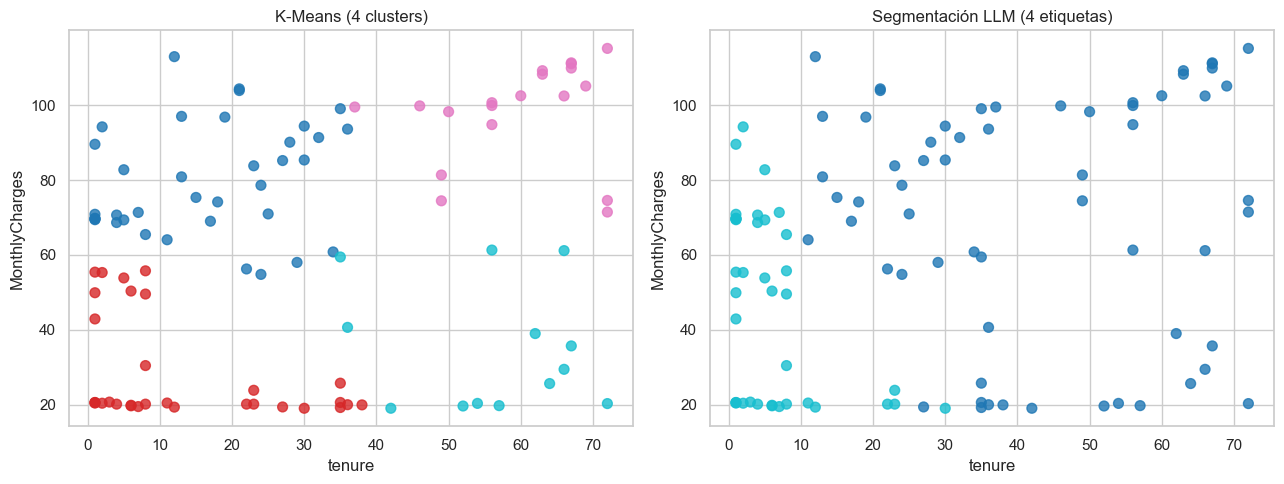

In [13]:
# --- Visualización lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(sub['tenure'], sub['MonthlyCharges'], c=sub['cluster_km'],
                cmap='tab10', s=50, alpha=0.8)
axes[0].set_xlabel('tenure'); axes[0].set_ylabel('MonthlyCharges')
axes[0].set_title('K-Means (4 clusters)')

# Mapeamos las etiquetas del LLM a colores
codes = pd.Categorical(sub['segmento_llm'], categories=SEGMENTOS).codes
sc = axes[1].scatter(sub['tenure'], sub['MonthlyCharges'], c=codes,
                     cmap='tab10', s=50, alpha=0.8)
axes[1].set_xlabel('tenure'); axes[1].set_ylabel('MonthlyCharges')
axes[1].set_title('Segmentación LLM (4 etiquetas)')
plt.tight_layout(); plt.show()

### 4.3 Lectura de los resultados — segmentación

Lo que se observa típicamente:

- **El LLM agrupa por reglas explícitas** (las que pusimos en el system prompt) — esto es interpretable y fácil de explicar al negocio.
- **K-Means agrupa por geometría** de los datos — captura patrones que tú no le dijiste, pero los centroides no tienen "nombre" hasta que tú los etiquetas.
- **Concordancia parcial**: en la tabla de contingencia se ven correspondencias claras (un cluster K-Means de "antiguos con alto total" ≈ LEAL_ALTO_VALOR), pero también divergencias.
- **Costo**: K-Means para 100 clientes corre en 1 ms. El LLM tardó segundos y costó milicentavos. Para segmentar la base completa de 7000 clientes el LLM serían ~$0.10 y unos minutos; K-Means sería instantáneo y gratis.

## 5. Cuándo usar LLM y cuándo modelo clásico

| Escenario | Mejor opción | Por qué |
|---|---|---|
| Tienes **dataset etiquetado grande** y features tabulares | Modelo clásico (LR, RF, XGBoost) | Calidad parecida o mejor, ×1000 más barato y rápido |
| **Sin datos etiquetados** y necesitas resultados ya | LLM zero/few-shot | El LLM "trae" conocimiento del mundo |
| Volumen de inferencia **muy alto** (millones/día) | Modelo clásico | El costo del LLM se vuelve prohibitivo |
| Datos son **texto libre, imágenes, audio** | LLM (especialmente multimodal) | Los modelos clásicos requieren mucho feature engineering |
| Necesitas **explicar la decisión** en lenguaje natural | LLM | Le pides que justifique la respuesta |
| **Latencia crítica** (< 50 ms) | Modelo clásico | El round-trip a la API ya consume eso |
| Datos **sensibles** que no pueden salir de tu infra | Modelo clásico o LLM open local (Ollama) | Privacidad |
| **Pocos ejemplos** (decenas, no miles) | LLM few-shot | Modelo clásico haría overfitting |
| **Tarea cambia constantemente** | LLM con prompt updates | No hay que reentrenar |

### Patrones híbridos que funcionan

- **LLM como labeler** → genera etiquetas con LLM (caro pero una sola vez) → entrena un modelo clásico sobre esas labels (barato en producción).
- **Modelo clásico + LLM para explicar** → la regresión logística predice, el LLM redacta una explicación amigable.
- **LLM extrae features estructurados** de texto/imagen → modelo tabular clásico predice el target.

## 6. Conclusión

Los LLMs no son un reemplazo universal de los modelos clásicos — son **otra herramienta** del cinturón. La pregunta correcta no es _"¿LLM o modelo clásico?"_ sino:

> _¿Qué combinación de **datos disponibles + restricciones de costo y latencia + necesidad de explicabilidad + tipo de input** tengo, y qué herramienta encaja mejor?_

La regresión logística que entrenamos en el módulo 1 sigue siendo la opción correcta para predecir churn cuando hay datos etiquetados y volumen alto. El LLM brilla cuando entran texto libre, imágenes, contextos cambiantes, o no hay etiquetas con qué entrenar.

## 7. Referencias

- Brown, T. et al. (2020). *Language Models are Few-Shot Learners*. https://arxiv.org/abs/2005.14165
- Liu, P. et al. (2023). *Pre-train, Prompt, and Predict: A Systematic Survey of Prompting Methods in NLP*. https://arxiv.org/abs/2107.13586
- Hegselmann, S. et al. (2023). *TabLLM: Few-shot Classification of Tabular Data with Large Language Models*. https://arxiv.org/abs/2210.10723
- Wang, R. et al. (2024). *LLMs for Tabular Data: A Survey*. https://arxiv.org/abs/2402.17944
- Dataset Telco Churn: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Notebook 04 del módulo 1 (regresión logística baseline) y notebook 02 del módulo 2 (K-Means baseline) — dentro de este mismo repo.